# Visualization and Exploratory Data Analysis

The objective of this notebook is to learn how to explore a dataset with classical visualization tools.

We will organize the analysis in three levels:
1. **Univariate analysis**: one variable at a time.
2. **Bivariate analysis**: relationships between two variables.
3. **Multivariate analysis**: several variables at the same time.

We use the `customers.csv` dataset. Each row is a customer, and each column gives yearly spending in one product category.


In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Setup code provided: run this cell first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

sns.set_theme(style="whitegrid", context="notebook")


## Dataset Loading

Q1. Load the data and describe elementary statistics.

**Code clues:** use `pd.read_csv(...)` to load the file, then explore it with `.head()`, `.info()`, and `.describe()`.


In [4]:
# Load customers.csv into a DataFrame named data and inspect it.
# Write your code here.
customers = pd.read_csv('customers.csv')
display(customers.head())
display(customers.info())
display(customers.describe())

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicatessen      440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


None

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## 1. Univariate Analysis

We first study each variable separately. This helps us answer simple questions:
- What are the typical values?
- Are the distributions symmetric or skewed?
- Are there extreme values?


### Histograms

Q2. Draw a histogram for each variable. What do you notice about the distributions?

**Code clues:** create a grid with `plt.subplots(...)`, flatten the axes with `.ravel()`, loop over `data.columns`, and draw each distribution with `sns.histplot(..., kde=True, ax=ax)`. Finish with `plt.tight_layout()`.


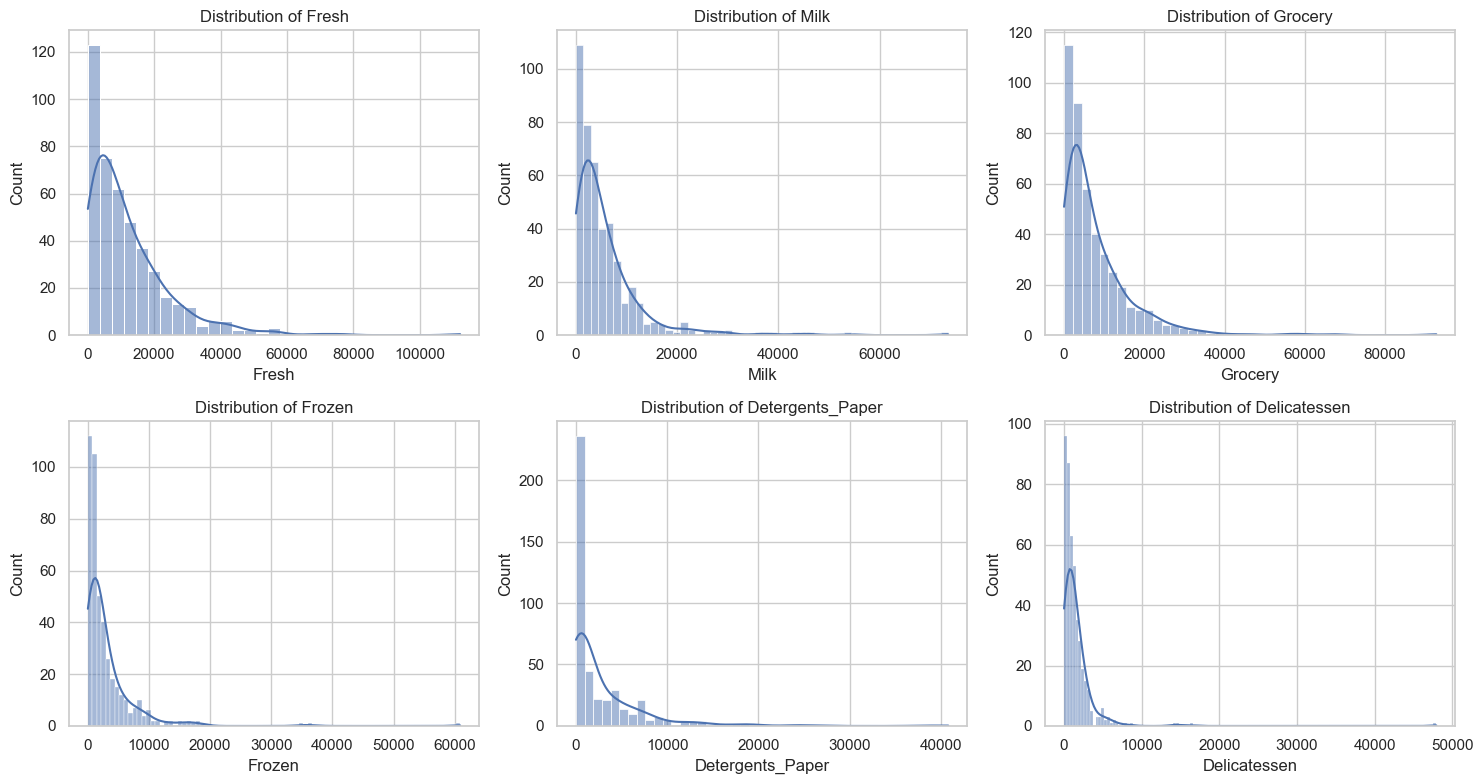

In [ ]:
# Draw one histogram per variable.
# Write your code here.
#plt.subplots().ravel()
#---------------------------------
# num_cols = len(customers.columns)
# n_cols = 3  # Number of grid columns
# for c in customers.columns:
#     #sns.histplot(c, kde=True, ax=ax)
#     plt.hist(customers[c])
#     plt.show()
#plt.hist(customers["Fresh"])
#plt.show()
#plt.tight_layout()
#Distributions are almost the same for each variable
#-----------------------------------

# 1. Determine layout dimensions based on the number of columns
num_cols = len(customers.columns)
n_cols = 3  # Number of grid columns
n_rows = (num_cols + n_cols - 1) // n_cols  # Calculate required rows

# 2. Create the grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# 3. Flatten the 2D axes array into a 1D loopable array
axes_flat = axes.ravel()

# 4. Loop over columns and plot each variable onto its assigned axis
for i, col in enumerate(customers.columns):
    sns.histplot(data=customers, x=col, kde=True, ax=axes_flat[i]) #x is column name, kde=True overlays a smooth curve on top of the bar (density), ax=axes_flat[i] where to draw that curve
    axes_flat[i].set_title(f"Distribution of {col}")

# 5. Hide any unused empty subplot axes in the grid
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 6. Adjust spacing to prevent overlapping labels
plt.tight_layout()
plt.show()

### Boxplots

Q3. Draw boxplots for all variables. Which variables have the largest spread?

**Code clues:** `sns.boxplot(data=data)` draws all numerical columns together. Use `plt.figure(...)` to choose the size and `plt.xticks(rotation=...)` if labels overlap.


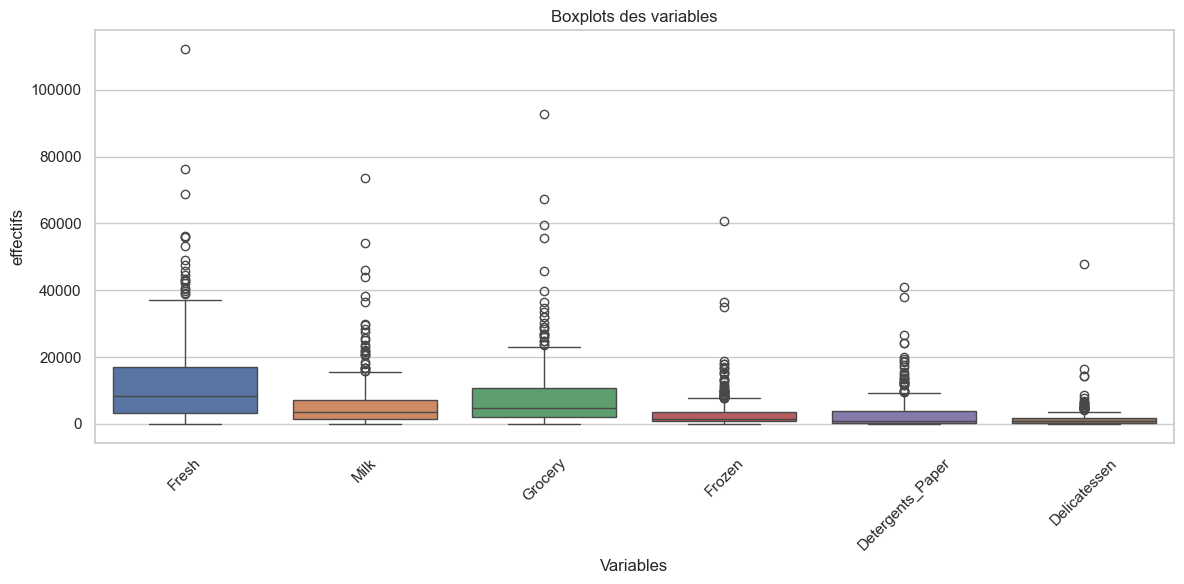

In [52]:
# Draw and label the boxplots.
# Write your code here.
#for v in customers.columns:
    #sns.boxplot(data = customers[v])
# sns.boxplot(data = customers)
#help(plt.figure)
# plt.figure(figsize=(1000, 1000))
#help(plt.xticks)
#plt.xticks(rotation= )

plt.figure(figsize=(12, 6)) #lines, columns

sns.boxplot(data=customers)
plt.xlabel("Variables")
plt.ylabel("effectifs")
plt.title("Boxplots des variables")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Fresh and grocery have a largest spread


### Violin Plots

Q4. Draw violin plots. They show both the spread and the shape of each distribution.

**Code clues:** use `sns.violinplot(data=data)`. The figure-size and label-rotation functions are the same as for the boxplot.


Text(0, 0.5, 'effectifs')

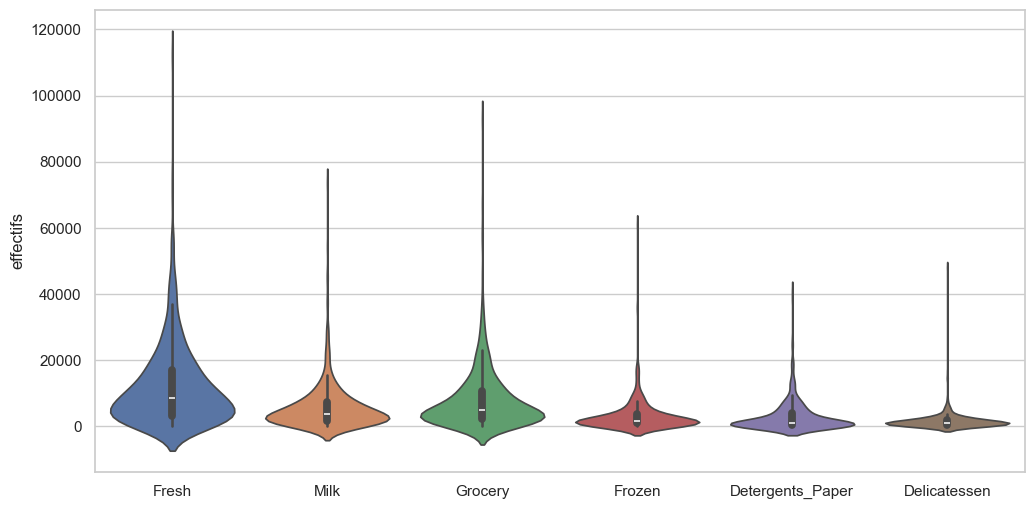

In [34]:
# Draw and label the violin plots.
# Write your code here.
plt.figure(figsize=(12, 6)) #width, height in inches
sns.violinplot(data=customers)
plt.ylabel("effectifs")




### Log transformation

The spending variables are strongly skewed: most customers have moderate spending, while a few customers spend much more.

A logarithmic transformation is useful here because it reduces the effect of very large values.

Create the transformed data with `np.log(data)`, then reuse your histogram and violin-plot code with the transformed DataFrame.


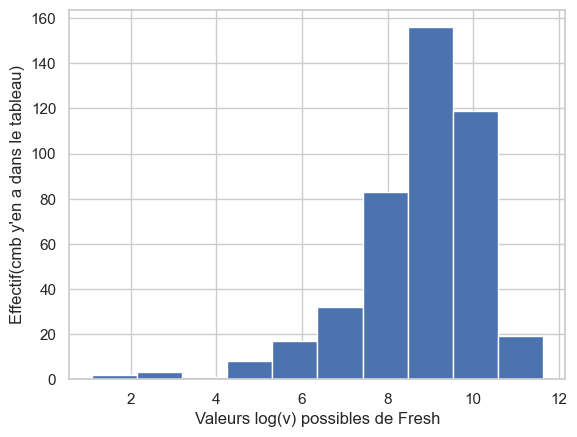

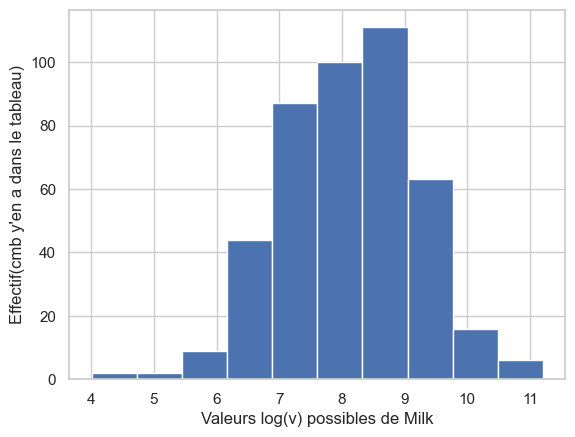

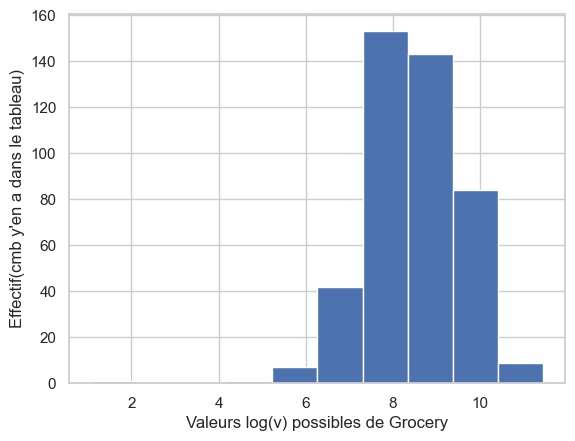

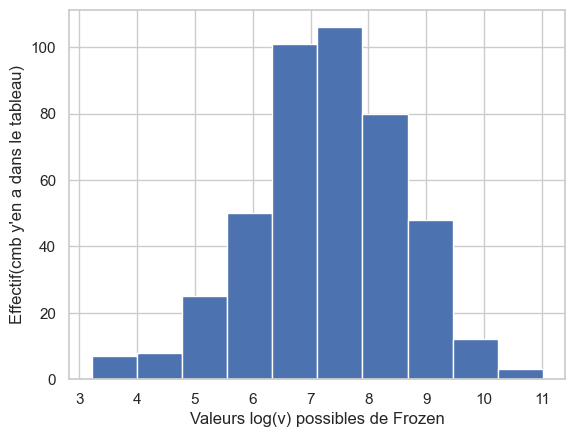

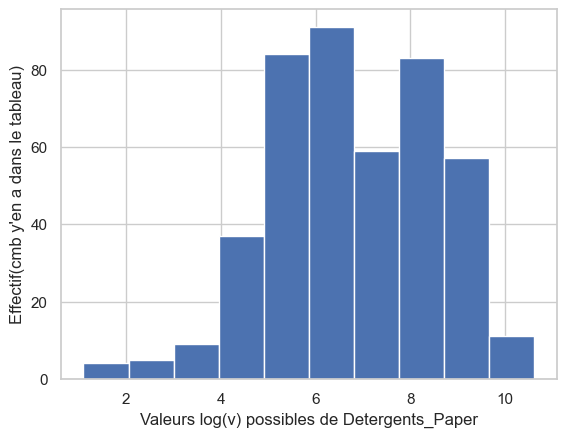

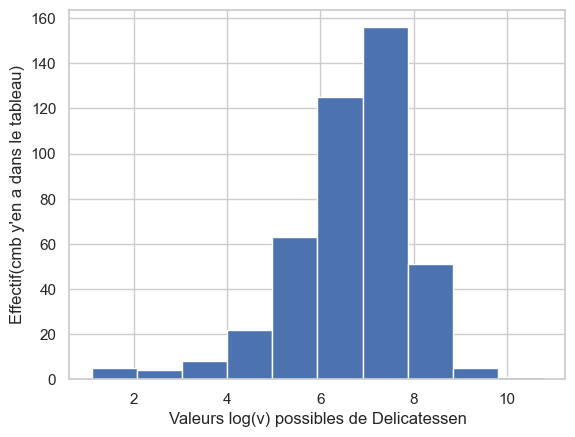

In [44]:
# Create a DataFrame named log_data and redraw the histograms.
# Write your code here.
cust_log = np.log(customers)
for c in cust_log.columns:
    plt.hist(cust_log[c])
    plt.xlabel("Valeurs log(v) possibles de "+c)
    plt.ylabel("Effectif(cmb y'en a dans le tableau)")
    plt.show()
# plt.ylabel("")

Text(0, 0.5, 'effectifs')

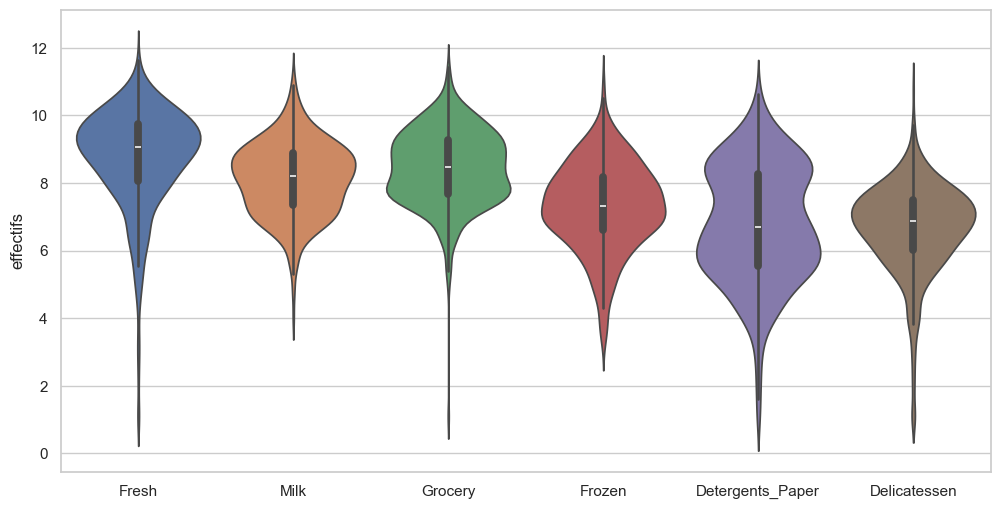

In [45]:
# Draw violin plots of the log-transformed data.
# Write your code here.
plt.figure(figsize=(12, 6)) #width, height in inches
sns.violinplot(data=cust_log)
plt.ylabel("effectifs")


## 2. Bivariate Analysis

We now study relationships between two variables at a time.

Q5. Start with one scatter plot. Do customers who spend more in one category also tend to spend more in another?

**Code clues:** use `sns.scatterplot(data=log_data, x=..., y=...)`. Choose two column names for `x` and `y`; `Grocery` and `Detergents_Paper` are an informative pair.



<Axes: xlabel='Grocery', ylabel='Detergents_Paper'>

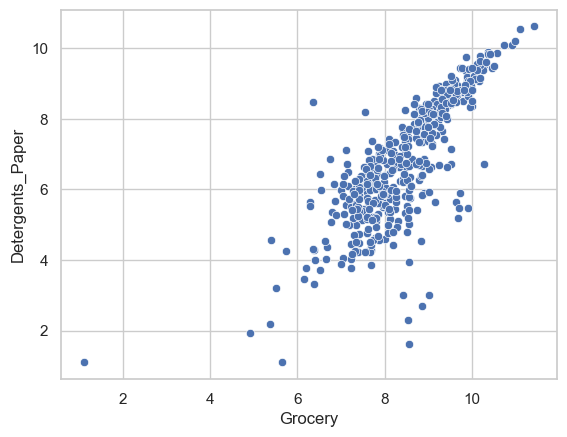

In [ ]:
# Draw and label a scatter plot for two spending categories.
# Write your code here.
sns.scatterplot(data=cust_log, x = "Grocery", y = "Detergents_Paper") #Yes for this pair it seems to be true for : customers who spend more in one category also tend to spend more in another
# sns.scatterplot(data=cust_log, x = "Fresh", y = "Delicatessen")

### Scatter Plot with a Regression Line

Q6. Add a regression line to make the trend easier to read.

**Code clues:** replace the scatter-plot function with `sns.regplot(...)`. It accepts the same `data=`, `x=`, and `y=` arguments; `scatter_kws={"alpha": 0.6}` makes overlapping points easier to see.


<Axes: xlabel='Grocery', ylabel='Detergents_Paper'>

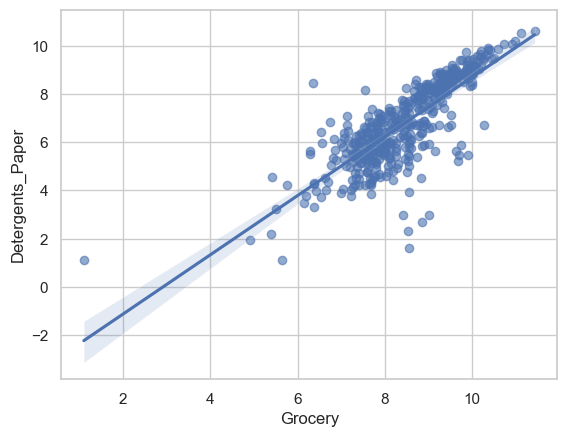

In [50]:
# Redraw your scatter plot with a regression line.
# Write your code here.
sns.regplot(data=cust_log, x = "Grocery", y = "Detergents_Paper",scatter_kws={"alpha": 0.6} )

### Pairwise Scatter Plots

Q7. Draw a scatter matrix for all pairs of variables.

**Code clues:** `sns.pairplot(log_data, diag_kind="kde", corner=True)` creates all pairwise plots at once.


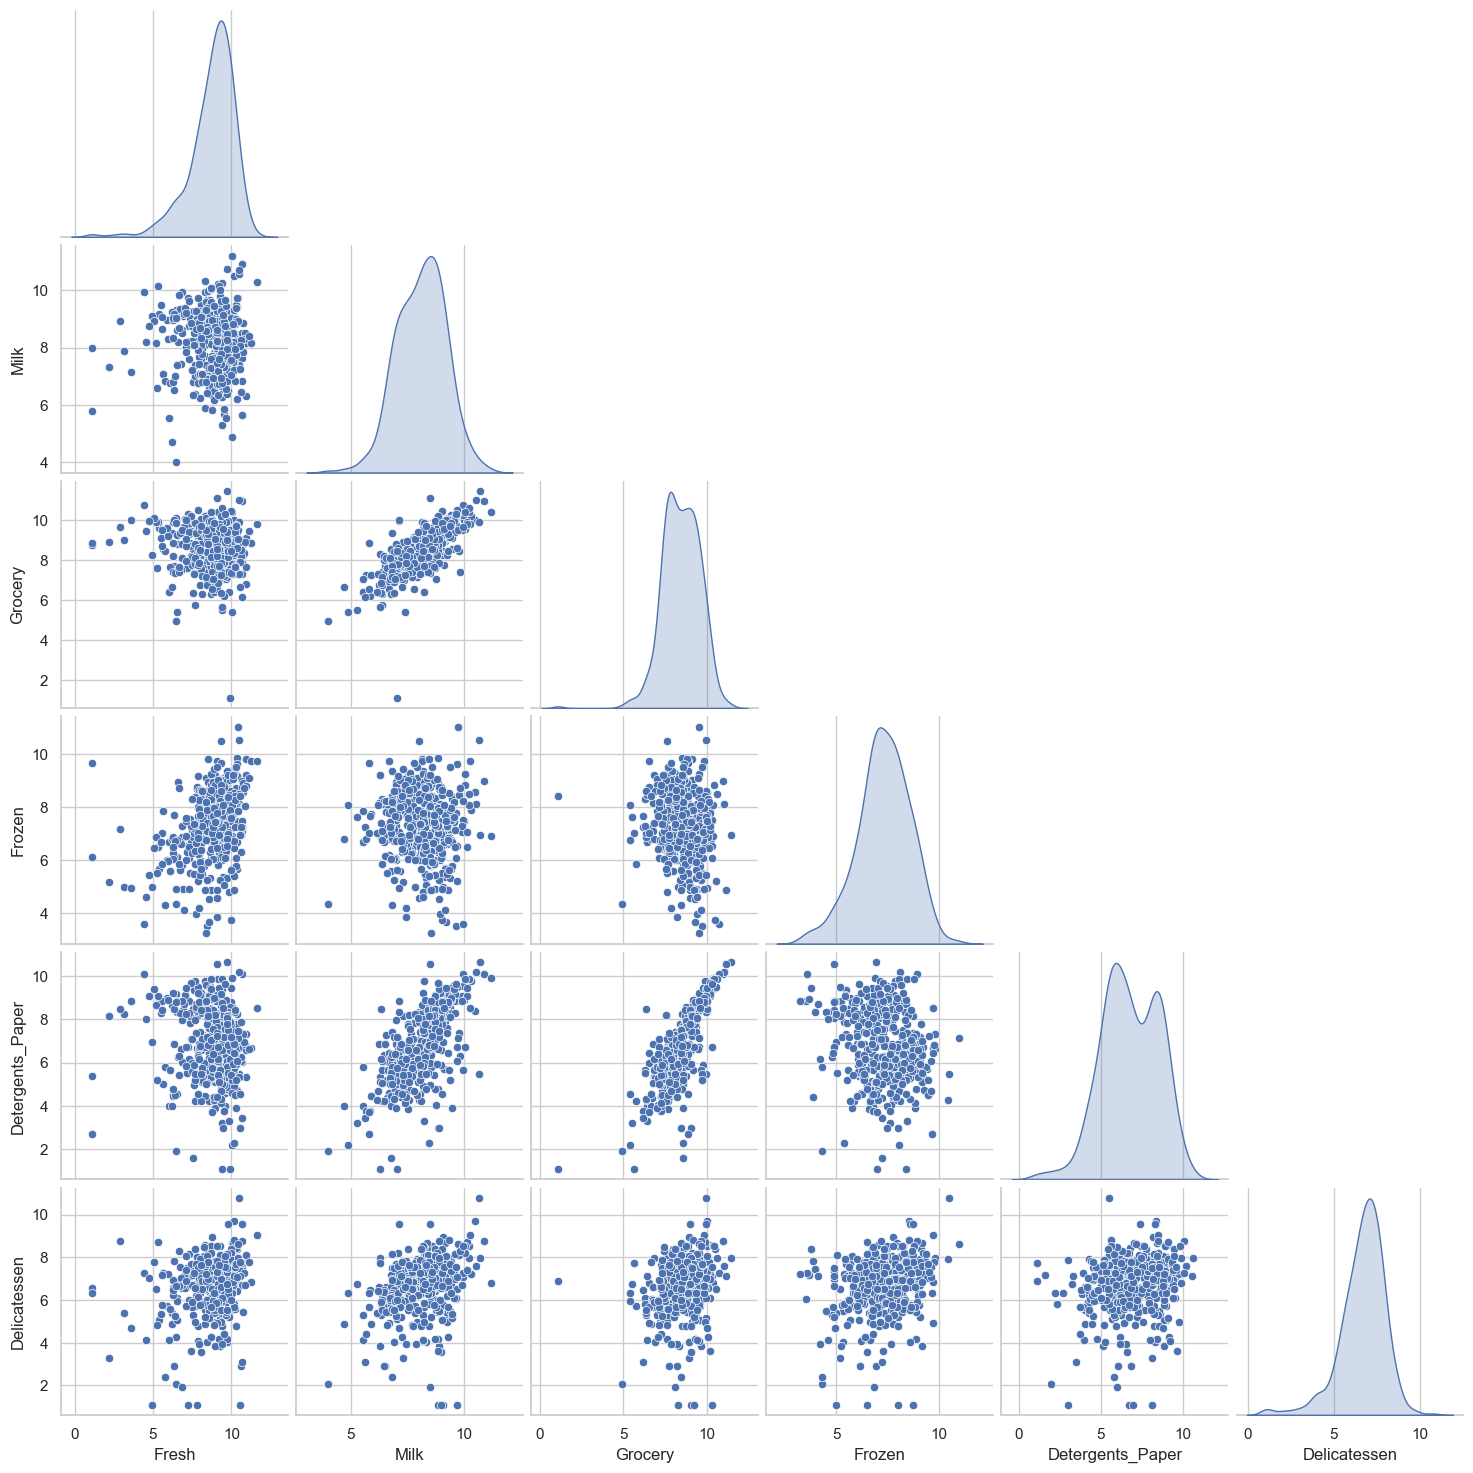

In [ ]:
# Draw the pairwise plots and examine the result.
# Write your code here.
sns.pairplot(cust_log, diag_kind="kde", corner=True )
#We just see the correlation between each pair of variable

### Correlation Matrix

Q8. Draw the correlation matrix. Which pairs of variables are most strongly related?

**Code clues:** calculate correlations with `log_data.corr()`, then pass the result to `sns.heatmap(...)`. Useful options are `annot=True`, `center=0`, `cmap="vlag"`, and `fmt=".2f"`.


<Axes: >

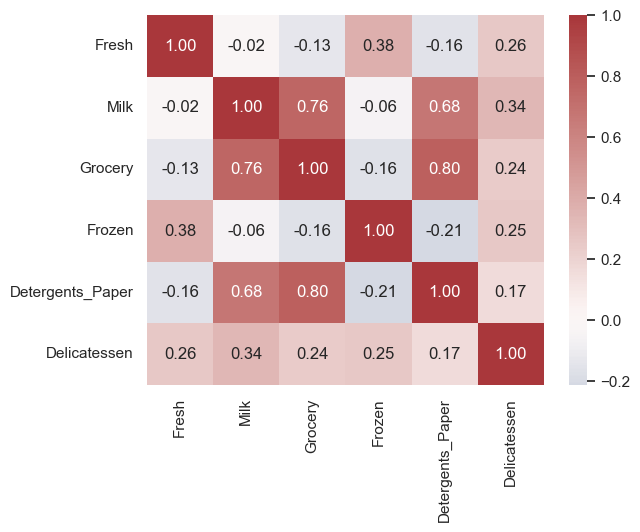

In [ ]:
# Calculate and visualize the correlation matrix.
# Write your code here.
cor = cust_log.corr()
sns.heatmap(cor, annot=True,center=0, cmap="vlag",fmt=".2f")
#The most strongly realted are the pairs Grocery Milk(0.76), Detergents_Papr Grocery (0.80) and Detergents_paper Milk(0.68)

## 3. Multivariate Analysis

We now visualize all variables together. Because the variables do not have the same scale, we standardize the log-transformed data before comparing them.

**Code clues:** apply `preprocessing.StandardScaler().fit_transform(log_data)`, then wrap the resulting array in `pd.DataFrame(...)`. Reuse `log_data.columns` and `log_data.index` so labels are preserved.


In [ ]:
# Standardize log_data and store the result in scaled_log_data.
# Write your code here.
all_vars = preprocessing.StandardScaler().fit_transform(cust_log)
scaled_cust_log = pd.DataFrame(all_vars, cust_log.index,cust_log.columns)
display(scaled_cust_log)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,0.484561,0.976070,0.439132,-1.508418,0.643001,0.407685
1,0.088766,0.990718,0.650291,0.134683,0.764127,0.623967
2,0.017680,0.890970,0.453606,0.377147,0.802243,1.758420
3,0.515656,-0.957573,-0.083722,1.140446,-0.324282,0.629110
4,0.876512,0.439720,0.395003,0.756909,0.405285,1.442246
...,...,...,...,...,...,...
435,1.060925,1.181199,1.112977,1.700316,-0.920248,0.788867
436,1.249064,-0.791491,-1.616824,0.867177,-1.310814,0.836554
437,0.577315,1.413502,1.682525,-0.951977,1.639949,0.662131
438,0.343877,-0.490392,-0.655228,-0.277726,-0.966810,0.760989


### Heatmap of Standardized Values

Q9. Draw a heatmap of the standardized data. Each row is a customer and each column is a spending category.

**Code clues:** use `sns.heatmap(scaled_log_data, ...)`. A diverging palette such as `cmap="vlag"` with `center=0` distinguishes below-average and above-average values; `yticklabels=False` keeps the plot readable.


Text(74.44444444444444, 0.5, 'customers')

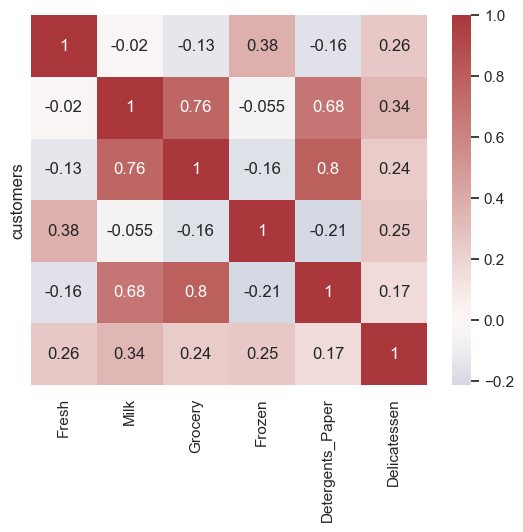

In [63]:
# Draw the standardized-data heatmap.
# Write your code here.
sns.heatmap(scaled_cust_log.corr(), annot=True, cmap ="vlag" , center=0, yticklabels=False) # ATTENTION à mettre scaled_cust_log.corr()
plt.ylabel("customers")

### Clustermap

Q10. Finish with a clustermap. This is still an exploratory visualization: it displays the same standardized data, but automatically reorders rows and columns so similar profiles appear close to each other.

We will study clustering methods later; for now, use this plot as a visual summary of customer profiles.

**Code clues:** use `sns.clustermap(scaled_log_data, ...)`. The same `cmap=`, `center=`, and `yticklabels=` options used for the heatmap also work here.


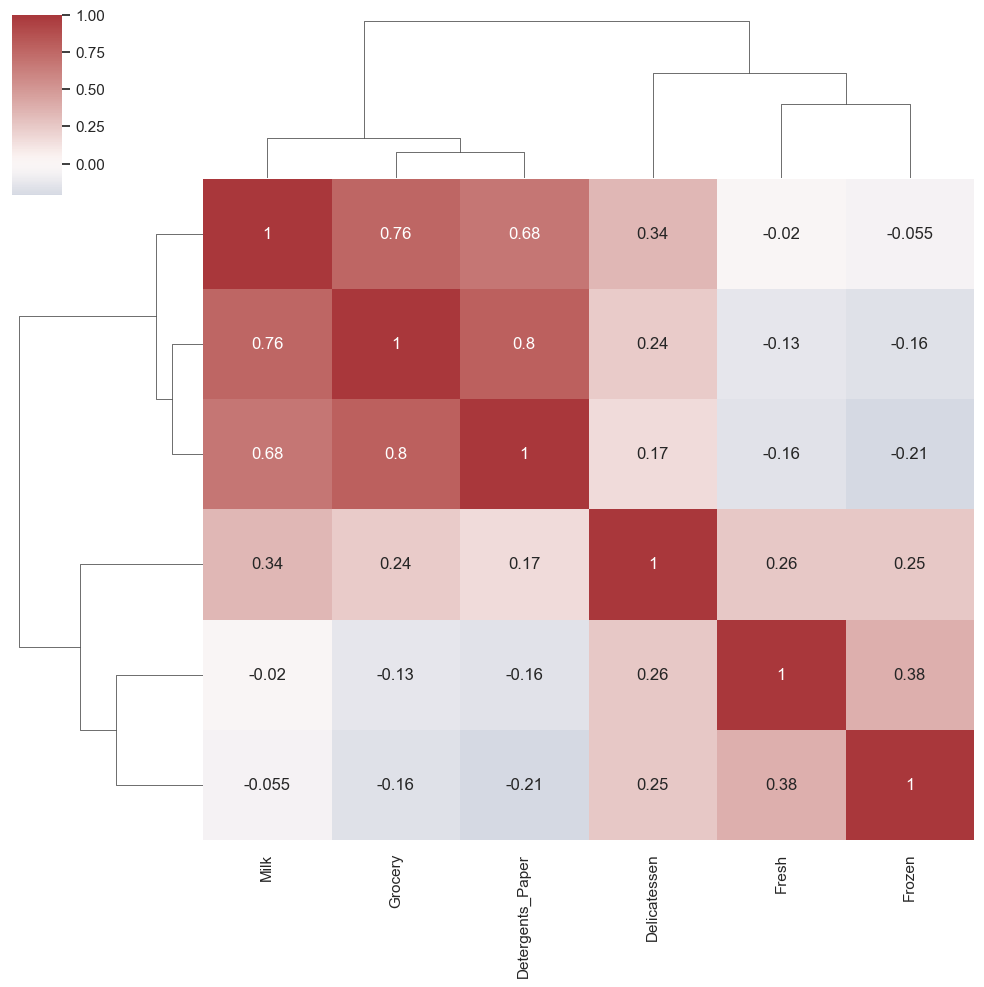

In [65]:
# Draw the clustermap and inspect the reordered rows and columns.
# Write your code here.
sns.clustermap(scaled_cust_log.corr(), annot=True, cmap ="vlag" , center=0, yticklabels=False)

## Question

Q13. In the clustermap, can you identify groups of customers with similar spending profiles? Which variables seem to define these profiles?


Answer: Milk Grocery and Detergent Paper have similar spending profiles



## Exploration tools
To quickly visualize various information about your dataframe, you can use a dedicated tool. For instance, install the `dtale` package and apply it to your dataframe using the `dtale.show(df)` function.

You can directly explore many aspects of your data from a browser.

You could also use packages such as `DataPrep`, `SweetViz`, `AutoViz`, etc.
